In [ ]:
#Imports packages
from distmesh import *
import numpy as np
import matplotlib.pyplot as plt
import scipy

(200, 2) (200, 2)
(400, 2)
count =  200 displacement =  0.00942843450099287
count =  400 displacement =  0.007768389900331755


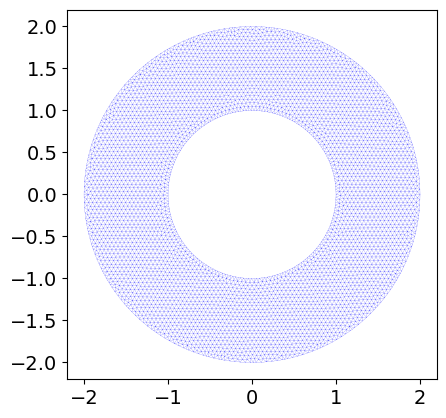

In [ ]:
#Initial values
n = 200
t = np.linspace(0,2*np.pi*(n/(n+1)),n)
h0 = 0.05

#Fixed points on boundary
x = np.linspace(0, 2*np.pi, n)
pfix1 = np.array([np.cos(x), np.sin(x)]).T
pfix2 = np.array([2*np.cos(x), 2*np.sin(x)]).T
pfix = np.vstack((pfix1, pfix2))

#Distance function
def dfunc(p): 
    d0 = dcircle(p, 0, 0, 2)
    d1 = dcircle(p, 0, 0, 1)
    return ddiff(d0, d1)


bbox = [-2, 2, -2, 2] # the bounding box
pts,tri = distmesh2D(dfunc,huniform,h0,bbox,pfix) #Gets mesh

4749
(398,)


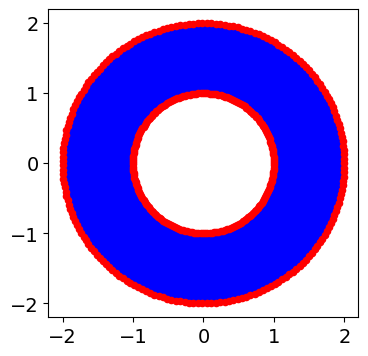

In [ ]:
#Gets indices of points on interior/exterior boundary points
def get_bdry(verts):
    r = np.sqrt(verts[:, 0]**2 + verts[:, 1]**2)
    tol = 1e-12 

    idx_inner = np.where(np.abs(r - 1) < tol)[0]
    idx_outer = np.where(np.abs(r - 2) < tol)[0]
    return idx_inner, idx_outer

#Dirichlet boundary
(inner, outer) = get_bdry(pts)
dirichlet_bdry = np.concatenate((inner,outer))

#Plots it just to check
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize = (4,4))
plt.triplot(pts[:,0],pts[:,1],tri, c='blue')    
plt.scatter(pts[dirichlet_bdry,0],pts[dirichlet_bdry,1],s=20,c="red")  
plt.show()

In [83]:
# define finite element functions
def triarea2(verts):
    Aux = np.ones((3,3))
    Aux[1:3,:] = np.transpose(verts)
    return np.linalg.det(Aux)

def stima3(verts):
    Aux = np.ones((3,3))
    Aux[1:3,:] = np.transpose(verts)
    rhs = np.zeros((3,2))
    rhs[1,0] = 1
    rhs[2,1] = 1
    G = np.zeros((3,2))
    G[:,0] = np.linalg.solve(Aux,rhs[:,0])
    G[:,1] = np.linalg.solve(Aux,rhs[:,1])
    det = np.linalg.det(Aux)
    MA = 0.5*det*np.matmul(G,np.transpose(G))
    MB = det*np.array([[2,1,1],[1,2,1],[1,1,2]])/24
    return MA,MB


def InitialCondition(verts):
    return np.sqrt(verts[:,0]**2 + verts[:,1]**2) + np.cos(np.arctan2(verts[:,1], verts[:,0]))

def SourceFun(verts,t):
    return 1

In [ ]:
# visualization
def visualize(pts,tri,u,str_title,str_file_name):
    plt.rcParams.update({'font.size': 14})
    fig, ax = plt.subplots(figsize = (4,4))
    umax = np.max(u)
    umin = np.min(u)
    plt.tricontourf(pts[:,0], pts[:,1],tri,u,np.linspace(umin,umax,60))
    plt.colorbar()
    plt.title(str_title)
    ax.set_aspect('equal')
    plt.savefig(str_file_name)

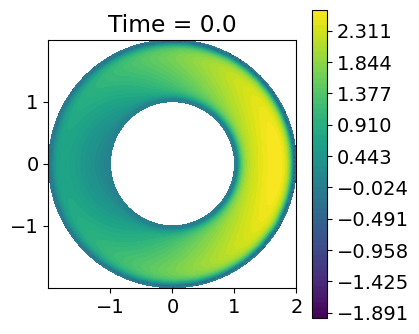

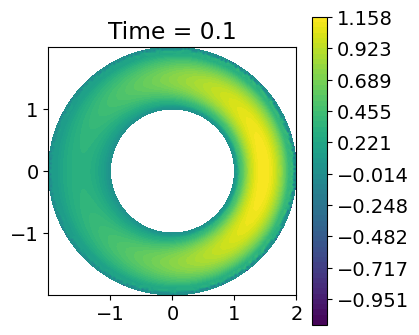

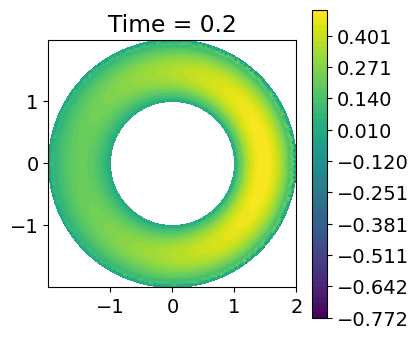

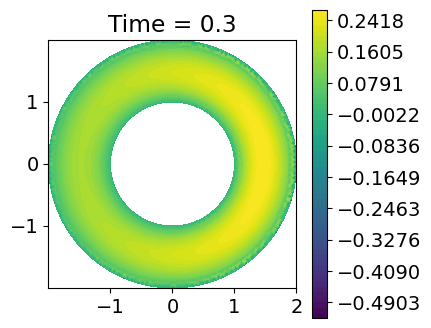

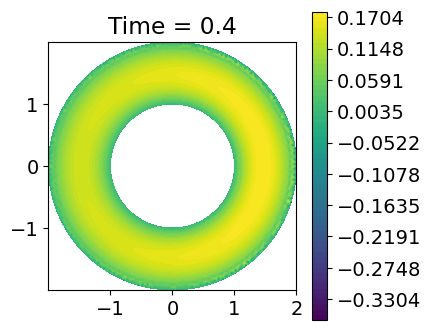

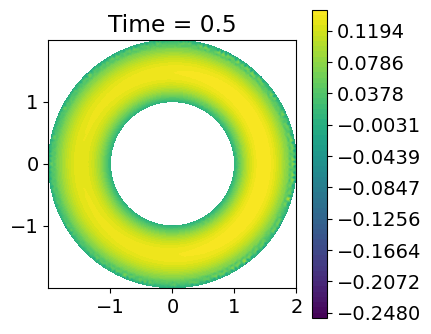

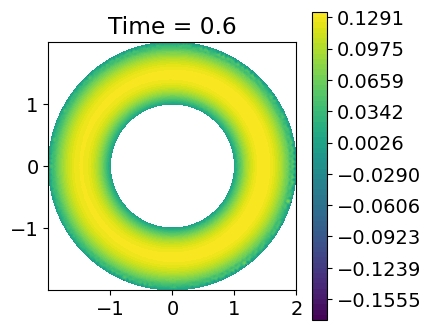

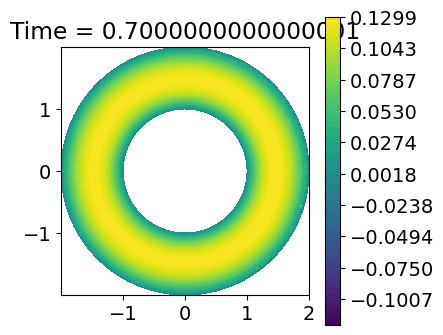

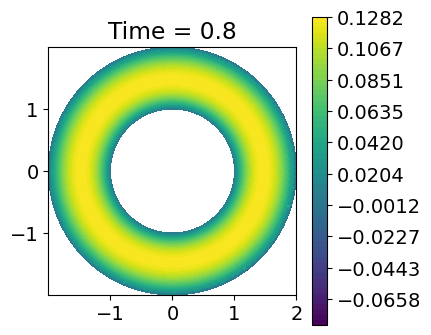

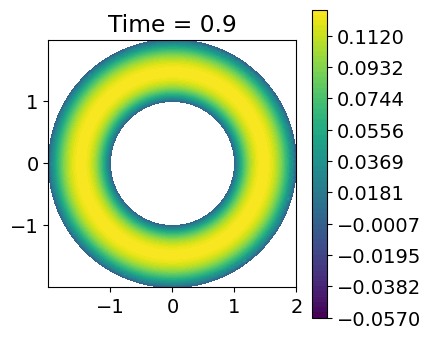

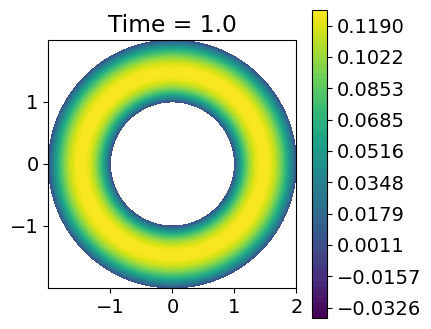

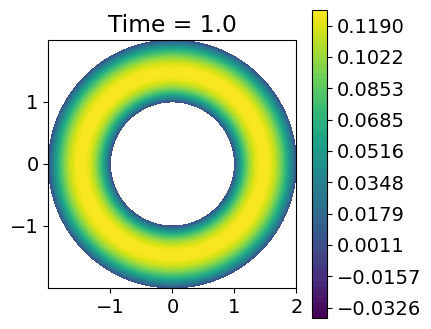

In [ ]:
#Assembles these M and K matrices that as set up in writing
def assemble_global_matrices(pts, tri):
    n_nodes = len(pts)
    I, J, K_vals, M_vals = [], [], [], []

    for t in tri:
        verts = pts[t]
        MA, MB = stima3(verts)
        for i in range(3):
            for j in range(3):
                I.append(t[i])
                J.append(t[j])
                K_vals.append(MA[i, j])
                M_vals.append(MB[i, j])

    K_global = scipy.sparse.csr_matrix((K_vals, (I, J)), shape=(n_nodes, n_nodes))
    M_global = scipy.sparse.csr_matrix((M_vals, (I, J)), shape=(n_nodes, n_nodes))
    
    return K_global, M_global

#Helper to fix boundary
def fix_row(A, b, row_idx, value):
    start = A.indptr[row_idx]
    end = A.indptr[row_idx + 1]
    
    A.data[start:end] = 0.0
    diag_idx = np.where(A.indices[start:end] == row_idx)[0]
    A.data[start + diag_idx] = 1.0
    b[row_idx] = value

K_global, M_global = assemble_global_matrices(pts, tri)
dt = 0.01
T_final = 1
u = InitialCondition(pts)
u[dirichlet_bdry] = 0

A_LHS = M_global + (dt/2)*K_global #Actual matrices used in updates
A_RHS = M_global - (dt/2)*K_global
L = M_global @ np.ones(len(pts))

u_n = u.copy()

#Update loop
for t in np.arange(0, T_final + dt, dt):
    b = A_RHS @ u_n + dt*L #B vector
    b[dirichlet_bdry] = 0 #Reforce boundary
    A_eff = A_LHS.copy().tocsr() 
    
    for idx in dirichlet_bdry: #Keeps things fixed
        fix_row(A_eff, b, idx, 0) 
    u_next = scipy.sparse.linalg.spsolve(A_eff, b)
    u_n = u_next

    if int(100*t) % 10 == 0: #Every 100 time steps plot the figure
        visualize(pts,tri,u_n,f"Time = {t}",f"fig_t={t}.pdf")

visualize(pts,tri,u_n,f"Time = {t}",f"fig_t={t}.pdf")

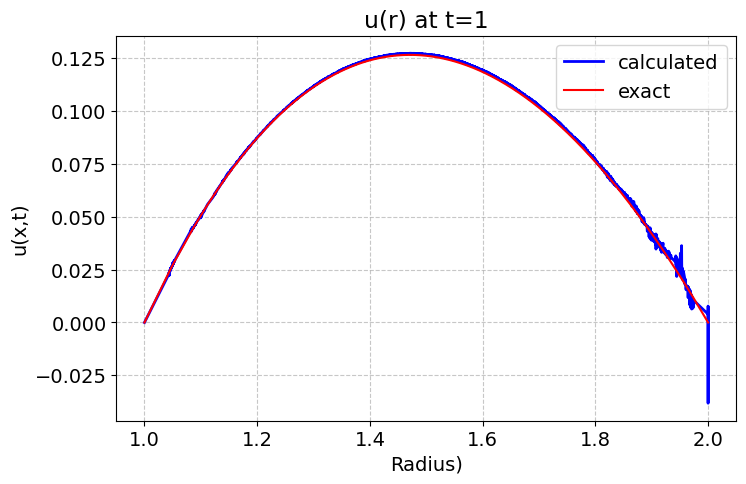

In [ ]:
u_final = u_n.copy()
#Gets r values
r = np.sqrt(pts[:, 0]**2 + pts[:, 1]**2)

#Gets calculated u(r)
isort = np.argsort(r)
rsort = r[isort]
usort = u_final[isort]

plt.figure(figsize=(8, 5))

#Plots both of them
plt.plot(rsort, usort, linewidth=2, color='blue', label='calculated')
plt.plot(rsort, (1-rsort**2)/4 + (3*np.log(rsort))/(4*np.log(2)), color='red', label='exact')

plt.xlabel('Radius)')
plt.ylabel('u(x,t)')
plt.title('u(r) at t=1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()